# Capstone, Final Report: Intraday Regime Classification in WTI Crude Oil Futures

Berkeley Professional Certificate in ML/AI, Module 24 (Final Report and Model).

This is the modelling follow-up to my Module 20.1 EDA, where I built and cleaned
the data and ran a first baseline. Here I do the full modelling: several model
families, each grid-searched and cross-validated, evaluated out of sample across a
long walk-forward, and then put through a P&L net of trading costs.

## Executive summary

I ask one question: can the next 60 minutes of WTI crude direction be predicted
from a battery of price, volatility, term-structure, open-interest and
options-implied signals? The target is the project's three-state regime: UP,
DOWN, MR (mean-reversion), defined to spec from forward vol-adjusted return and
forward path efficiency against per-fold quantiles, with the ambiguous windows
dropped.

The short answer: there is an edge, but it is smaller than the spread. Three model
families (penalised logistic regression, random forest, gradient boosting), each
tuned by grid search and run across about 155 monthly walk-forward folds, all land
in the same place: macro ROC-AUC about 0.53, a few points above chance. A
hypothesis test confirms the gap is real and not sampling noise. But "real" and
"tradeable" is not the same thing. Turned into a simple long/short strategy, the
signal earns under a basis point per trade gross (about +0.9 bps), and it leans on
the short side. That does not clear the cost of trading it: net of even a one-tick
round trip it is already negative, and at the 2 to 3 bps you actually pay to cross
in CL front month it is a clear loss. The edge is smaller than the bid-ask.

That is the honest result, and it is a statement about the market, not the model.
WTI front month is among the most efficient and most liquid markets in the world,
and on a one-hour horizon the little directional information that exists is already
priced to within transaction costs. A linear model and two non-linear ensembles
landing on the same spot says the ceiling sits in the data, not in the choice of
estimator. No single feature ranks the regime more than about 0.02 AUC above a
coin flip; the models reach 0.53 only by adding many faint signals together.

Where an edge could still hide, on this horizon, is in information this matrix does
not contain. On a 60-minute forecast the natural place to look is the order book:
depth, queue imbalance, trade flow derived from L2 data, none of which lives in a
bar-level matrix. And WTI is not traded in isolation. It sits in a macro context:
VIX, the crack spreads, the Brent-WTI spread, the dollar. Both are concrete next
steps, set out in Section 12.

## 1. Business understanding

A trading desk has a finite research budget and has to decide where to point it.
One recurring proposal is an intraday directional model on WTI crude oil: read
the order flow, the curve, the options surface, and predict whether the next
hour trends up, trends down, or chops sideways. If that prediction has an edge,
it funds a strategy. If it does not, the desk should know, fast and for
certain, and spend the budget elsewhere (sizing, execution, a different
horizon).

So the business question is not "build a model". It is "is there an edge here at
all, and if so how big". A clean negative is worth as much as a positive: it
stops good money chasing a pattern that is not there. That is the lens for this
report.

### Research question

Can the 60-minute-forward market regime of WTI crude, UP, DOWN, or MR, be
predicted, out-of-sample and net of look-ahead, from the engineered feature set
in the training matrix?

### What the three states mean (non-technical)

- UP: price moved up cleanly and persistently over the next hour. Trade: buy
  weakness.
- DOWN: price moved down cleanly and persistently. Trade: sell strength.
- MR: price oscillated with no net direction. Trade: fade the extremes.
- NO_TRADE: ambiguous windows the label deliberately refuses to call. Dropped,
  so the model only ever learns from clean examples.

The distinction that matters: a market that drifts up 0.2% while bouncing around
violently is not the same as one that walks up 0.2% in a straight line. The
first is MR, the second is UP. Telling them apart needs two measurements, not
one: return and path quality. That is exactly how the label is built.

### Why classification, not a time-series model like ARIMA

The obvious first reach on a price series is a classical time-series model: ARIMA
on the returns, GARCH on the variance. I do not use ARIMA here, for two reasons.

The target is a state, not a number. The regime label is UP, DOWN or MR, defined
from the forward vol-adjusted return AND the forward path efficiency against
per-fold quantiles. ARIMA forecasts the next value of a single series; it has no
way to say "clean trend" versus "choppy drift that ended higher", which is the
whole point of the label. The question is a classification, so I use classifiers,
and I let them read the full feature matrix (price, vol, term structure, open
interest, the options surface) that a univariate ARIMA cannot see.

ARIMA also only earns its keep if returns are linearly autocorrelated, and they
are not. A backward AR fit on the return predicts the next hour at essentially
zero out-of-sample R-squared and chance directional accuracy; the correlations in
Section 5.3 are those AR coefficients in disguise, and they sit at about zero. So
ARIMA on the mean would be a slower way to confirm the same null, not a new model.
The time-series tool that does work on this data is GARCH, but on the variance,
because volatility clusters. That is a different target, risk rather than
direction, and it is in the next steps.

### Stationarity and overlapping windows, and what they cost

Two assumptions deserve to be stated plainly, because both can flatter a model
that ignores them.

Stationarity. A single ARIMA fit over sixteen years assumes one stationary
process. Oil is not that: the 2014-16 OPEC price war, the 2020 collapse, the 2022
invasion are different regimes with different dynamics. I do not assume
stationarity globally. The walk-forward retrains every month on a trailing twelve,
and the label thresholds are recomputed on each training fold, so both the model
and the label adapt to the local regime instead of to a 16-year average.

Overlapping windows. Decisions are taken every minute, but each label looks sixty
minutes ahead, so two neighbouring rows share fifty-nine of their sixty forward
minutes. The rows are therefore heavily autocorrelated, not independent draws, and
that carries two costs I handle in the open:

- A mechanical autocorrelation. The raw AR(1) of the 60-minute return looks like
  0.98, but that number is the window overlap, not forecastable signal. The honest
  test is the forward, out-of-sample one, and it is flat.
- Understated uncertainty. Treating overlapping rows as independent shrinks the
  standard errors and inflates the effective sample size. The inferential tests in
  Section 9 lean on the spread across 155 near-independent monthly folds and on a
  label permutation, not on naive row-level errors, and the economic test in
  Section 10 trades non-overlapping one-hour holds, so a single move is not counted
  sixty times. These do not erase the dependence: the pooled bootstrap still treats
  rows as exchangeable, so that one interval is, if anything, a bit optimistic.

## 2. Setup

Runtime. End-to-end (load, EDA, grid search, the walk-forward across all folds
for three model families, the cost-aware P&L, the interpretation pass) runs in
under an hour on the workstation I use (a 100-core CPU with 1 TB of RAM). The
walk-forward and grid-search loops dominate; everything else is a small fraction.
On modest hardware, budget more.

Every figure is mirrored to images/ as it renders, via the show() wrapper
below, so the charts can be read without executing the notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import glob
import time
from pathlib import Path

import re
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

RNG = np.random.default_rng(0)        # one seed for every sampled/stochastic step

# Every figure is mirrored to images/ as a PNG. We wrap plt.show() so each chart
# is saved automatically, the filename is the slug of the figure title, so a
# re-run overwrites in place rather than accumulating numbered copies.
IMAGES = Path("images"); IMAGES.mkdir(exist_ok=True)
_orig_show = plt.show

def _fig_slug(fig):
    title = ""
    sup = getattr(fig, "_suptitle", None)
    if sup is not None:
        title = sup.get_text()
    if not title:
        for ax in fig.axes:
            if ax.get_title():
                title = ax.get_title(); break
    slug = re.sub(r"[^a-z0-9]+", "-", title.lower()).strip("-")[:60]
    return slug or "figure"

def show(*args, **kwargs):
    fig = plt.gcf()
    if fig.get_axes():
        fig.savefig(IMAGES / f"{_fig_slug(fig)}.png", dpi=110, bbox_inches="tight")
    return _orig_show(*args, **kwargs)

plt.show = show

SHARDS = sorted(glob.glob("data/matrix_*.parquet"))
assert SHARDS, "no matrix shards found in data/, see README"
total_mb = sum(Path(s).stat().st_size for s in SHARDS) / 1e6
print(f"{len(SHARDS)} matrix shards, {total_mb:.0f} MB on disk")

8 matrix shards, 686 MB on disk


## 3. Load matrix, clean, and describe

The matrix is the 5.28M-row, 73-column 1-minute spine: front-month WTI bars with
price, volatility, term-structure, open-interest and options-implied-vol features
attached, all built to the project's feature specification. The slow features
(term structure, open interest, the vol surface) are end-of-session quantities,
so they are carried at a one-session lag: a bar in session T sees session T-1's
settle, which is the most recent surface knowable intraday. Same convention a desk
actually trades on.

Cleaning here is about preparing the modelling panel, not repairing the source.
Three steps, each reported.

In [2]:
t0 = time.time()

# Column roles. Identifiers and raw OHLCV are not features; the two label
# ingredients (fwd_radj_60, fwd_E_60) are held out to build the target per fold;
# the boolean roll flags are used to clean, then dropped.
sch   = pl.scan_parquet(SHARDS[0]).collect_schema()
ALLC  = list(sch.keys())
IDENT = ["generic_symbol", "ts_event", "session_id", "source_contract"]
OHLCV = ["open", "high", "low", "close", "volume"]
INGR  = ["fwd_radj_60", "fwd_E_60"]
ROLL  = ["fwd_crosses_roll", "near_roll"]
FEATURES = [c for c in ALLC
            if c not in IDENT + OHLCV + INGR + ROLL
            and not str(sch[c]).startswith("Bool")]
print(f"{len(FEATURES)} model features; {len(INGR)} held-out label ingredients")

# Step 1, load the full spine (lazy scan -> single collect).
raw = pl.scan_parquet(SHARDS).collect()
n_raw = raw.height

# Step 2, roll-clean. Drop bars within +/-2 sessions of a contract roll
# (near_roll) and bars whose 60-min forward window would cross a roll
# (fwd_crosses_roll). Both would contaminate the forward label with a price
# series discontinuity rather than a market move.
clean = raw.filter((~pl.col("near_roll")) & (~pl.col("fwd_crosses_roll")))
n_roll = clean.height

# Step 3, drop rows where the forward label is unknowable (last 60 min of the
# sample, and the handful of NaN ingredients).
clean = clean.drop_nulls(INGR)
n_lab = clean.height

print(f"rows: raw {n_raw:,}  ->  roll-clean {n_roll:,}  ->  label-known {n_lab:,}")
print(f"dropped: {n_raw - n_roll:,} roll-contaminated ({(n_raw-n_roll)/n_raw:.1%}), "
      f"{n_roll - n_lab:,} label-unknowable ({(n_roll-n_lab)/n_roll:.1%})")

# Hand the modelling panel to pandas (sklearn-native). float32 keeps it ~1 GB.
panel = clean.select(FEATURES + INGR + ["ts_event"]).to_pandas()
TS = pd.to_datetime(panel["ts_event"], utc=True)
print(f"panel: {panel.shape[0]:,} x {panel.shape[1]}  "
      f"({panel.memory_usage(deep=True).sum()/1e6:.0f} MB)  loaded in {time.time()-t0:.1f}s")

60 model features; 2 held-out label ingredients
rows: raw 5,280,818  ->  roll-clean 4,084,066  ->  label-known 4,084,036
dropped: 1,196,752 roll-contaminated (22.7%), 30 label-unknowable (0.0%)


panel: 4,084,036 x 63  (1029 MB)  loaded in 0.3s


### 3.1 Duplicates and coverage

The spine key is (generic_symbol, ts_event). I check it is unique, and report
the date span and session count so the scale is on the page.

In [3]:
dup = raw.select(["generic_symbol", "ts_event"]).is_duplicated().sum()
print(f"duplicate (symbol, ts_event) rows: {dup}")
print(f"date span : {raw['ts_event'].min()} -> {raw['ts_event'].max()}")
print(f"sessions  : {raw['session_id'].n_unique():,}")
print(f"contracts rolled through (front): {raw['source_contract'].n_unique()}")

duplicate (symbol, ts_event) rows: 0
date span : 2010-06-06 22:00:00+00:00 -> 2025-12-12 21:58:00+00:00
sessions  : 3,942
contracts rolled through (front): 187


### 3.2 Missingness

Most features are dense. The structured missingness sits in the daily-grain
families, term structure, open interest, implied vol, early in the window and
around contract rolls, because those quantities are published once a session and
some back-month contracts did not trade every early session. I report the rate
per feature, then handle it inside the modelling pipeline rather than by
dropping rows: median imputation for the linear model, and native NaN handling
for the tree ensembles (random forest and gradient boosting both route a
missing value down whichever branch fits the training data best).

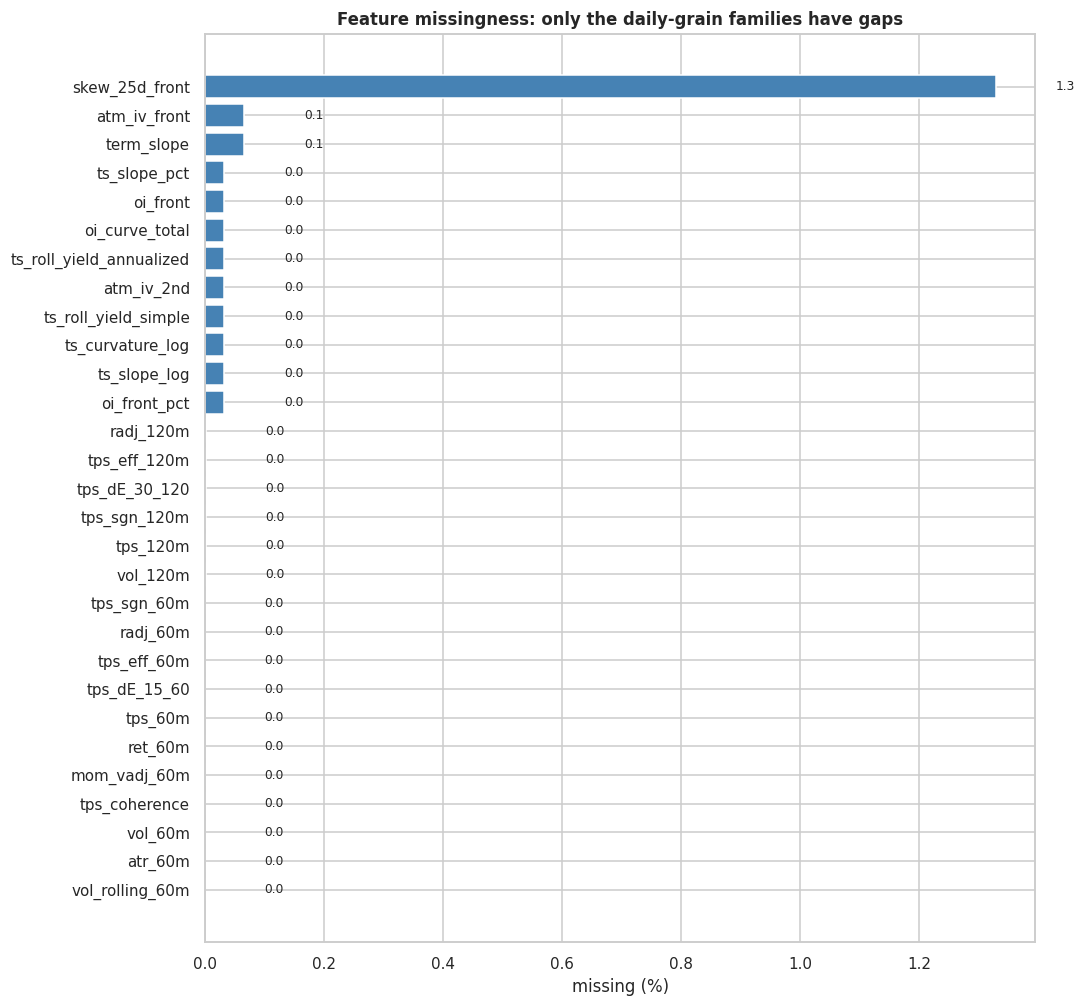

features with no missing values: 31 / 60


In [4]:
miss = (panel[FEATURES].isna().mean().sort_values(ascending=False) * 100)
top = miss[miss > 0]
fig, ax = plt.subplots(figsize=(10, max(3, 0.32 * len(top))))
ax.barh(top.index[::-1], top.values[::-1], color="steelblue")
ax.set_xlabel("missing (%)")
ax.set_title("Feature missingness: only the daily-grain families have gaps")
for i, v in enumerate(top.values[::-1]):
    ax.text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()
print(f"features with no missing values: {(miss == 0).sum()} / {len(FEATURES)}")

### 3.3 Descriptive statistics

A compact describe on a representative slice of the feature families, returns,
realised vol, the TPS family, the curve and the vol surface. Units differ by
family, which is why the linear models get a scaler.

In [5]:
desc_cols = ["ret_60m", "vol_60m", "atr_60m", "mom_vadj_60m", "sigma_t",
             "tps_60m", "tps_eff_60m", "radj_60m",
             "ts_slope_pct", "oi_front_pct", "atm_iv_front", "skew_25d_front"]
desc = panel[desc_cols].describe(percentiles=[.01, .25, .5, .75, .99]).T
desc = desc[["mean", "std", "1%", "25%", "50%", "75%", "99%"]]
desc.round(4)

,mean,std,1%,25%,50%,75%,99%
ret_60m,-0.0000,0.0051,-0.0135,-0.0015,0.0000,0.0016,0.0127
vol_60m,0.0005,0.0005,0.0001,0.0002,0.0004,0.0006,0.0019
atr_60m,0.0467,0.0384,0.0069,0.0203,0.0354,0.0608,0.1790
mom_vadj_60m,0.0921,6.7491,-15.5723,-4.4825,0.0000,4.6655,15.7882
sigma_t,0.0005,0.0006,0.0001,0.0002,0.0004,0.0006,0.0021
tps_60m,0.0098,0.5006,-1.4543,-0.1488,0.0000,0.1617,1.5320
tps_eff_60m,0.2864,0.2035,0.0000,0.1200,0.2500,0.4193,0.8298
radj_60m,0.0178,0.9133,-2.0946,-0.5955,0.0000,0.6227,2.1946
ts_slope_pct,0.0032,0.0248,-0.0261,-0.0055,0.0017,0.0060,0.0587
oi_front_pct,0.2050,0.0422,0.1289,0.1758,0.1974,0.2258,0.3194


## 4. The target: the spec regime label

The label follows the project's Label Definitions spec exactly. Each 60-minute
forward window gets two measurements:

- Vol-adjusted forward return, r-adj = forward log-return / (trailing per-minute
  vol times sqrt(horizon)). Return in units of standard deviations, a z-score
  of the move, so a calm-day move and a wild-day move of the same size are not
  confused.
- Path efficiency, E = |net displacement| / total distance travelled. One for a
  straight line, near zero for a round trip. It separates a clean trend from
  noisy chop that happened to end higher.

The four rules, with all thresholds taken as quantiles of the training fold (not
fixed numbers):

- UP   : r-adj > q70  AND  E > q60
- DOWN : r-adj < q30  AND  E > q60
- MR   : |r-adj| < q35  AND  E < q40
- NO_TRADE : everything else (dropped from training)

Quantiles, not fixed thresholds, are the crux. A fixed return cutoff fires
constantly in a volatile month and never in a calm one, so the model learns the
volatility regime instead of the trend. Per-fold quantiles adapt to whatever
regime the training window covers. The thresholds are therefore computed inside
the walk-forward, never as a static column, which is why the label ingredients,
not the label, live in the matrix.

In [6]:
# Label assignment, exactly as in the EDA generator. REG maps codes to names.
# The quantiles are computed per fold; here I compute them once on the whole
# panel only to visualise the label space, the modelling code recomputes them
# per training fold (Section 6).
REG = {0: "MR", 1: "UP", 2: "DOWN", -1: "NO_TRADE"}

def fold_quantiles(part):
    ra, e = part["fwd_radj_60"].to_numpy(), part["fwd_E_60"].to_numpy()
    return (np.quantile(ra, .70), np.quantile(ra, .30), np.quantile(e, .60),
            np.quantile(np.abs(ra), .35), np.quantile(e, .40))

def assign_labels(part, q):
    ra, e = part["fwd_radj_60"].to_numpy(), part["fwd_E_60"].to_numpy()
    y = np.full(len(ra), -1)                  # -1 = NO_TRADE (dropped)
    y[(ra > q[0]) & (e > q[2])] = 1           # UP
    y[(ra < q[1]) & (e > q[2])] = 2           # DOWN
    y[(np.abs(ra) < q[3]) & (e < q[4])] = 0   # MR
    return y

q_all = fold_quantiles(panel)
y_all = assign_labels(panel, q_all)
shares = pd.Series(y_all).map(REG).value_counts(normalize=True).reindex(
    ["UP", "DOWN", "MR", "NO_TRADE"]) * 100
print("class shares on the full panel (illustrative, global quantiles):")
for k, v in shares.items():
    print(f"  {k:9s} {v:5.1f}%")

class shares on the full panel (illustrative, global quantiles):
  UP         19.7%
  DOWN       19.0%
  MR         31.3%
  NO_TRADE   30.0%


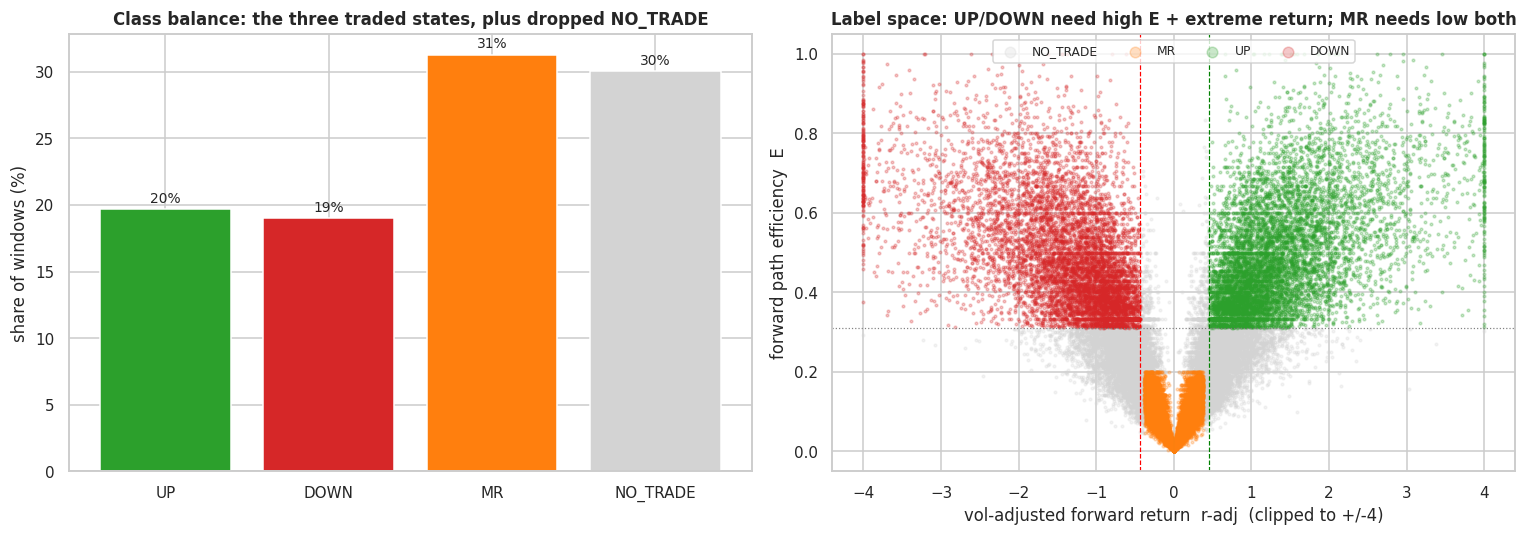

In [7]:
# Two-panel view of the target: the class balance, and the label as a region in
# the (r-adj, E) plane it is defined on.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"UP": "tab:green", "DOWN": "tab:red", "MR": "tab:orange", "NO_TRADE": "lightgrey"}
axes[0].bar(shares.index, shares.values, color=[colors[k] for k in shares.index])
axes[0].set_ylabel("share of windows (%)")
axes[0].set_title("Class balance: the three traded states, plus dropped NO_TRADE")
for i, v in enumerate(shares.values):
    axes[0].text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9)

# Sampled scatter in the (r-adj, E) plane, coloured by assigned label.
idx = RNG.choice(len(y_all), 40_000, replace=False)
ra = np.clip(panel["fwd_radj_60"].to_numpy()[idx], -4, 4)
e  = panel["fwd_E_60"].to_numpy()[idx]
lab = pd.Series(y_all[idx]).map(REG).to_numpy()
for k in ["NO_TRADE", "MR", "UP", "DOWN"]:
    m = lab == k
    axes[1].scatter(ra[m], e[m], s=3, alpha=0.25, color=colors[k], label=k)
axes[1].axvline(q_all[0], color="green", ls="--", lw=0.8)
axes[1].axvline(q_all[1], color="red", ls="--", lw=0.8)
axes[1].axhline(q_all[2], color="grey", ls=":", lw=0.8)
axes[1].set_xlabel("vol-adjusted forward return  r-adj  (clipped to +/-4)")
axes[1].set_ylabel("forward path efficiency  E")
axes[1].set_title("Label space: UP/DOWN need high E + extreme return; MR needs low both")
axes[1].legend(markerscale=4, loc="upper center", ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

## 5. Feature set and the central diagnostic

### 5.1 What the model sees

Sixty engineered features, no raw prices and no identifiers. Grouped by family:

- Price & momentum: multi-horizon returns, vol-adjusted momentum, the session
  return.
- Realised volatility: rolling vol and ATR at several windows, plus the
  trailing per-minute sigma the label is scaled by.
- TPS (Trend Persistence Score, Family J), the headline feature: vol-adjusted
  return times path efficiency, signed efficiency, efficiency trend, directional
  coherence, across five horizons.
- Term structure: curve slope, curvature, roll yield, months to expiry.
- Open interest: front-contract OI, curve total, front share.
- Vol surface: ATM IV front and second, term slope, 25-delta skew.
- Session clock: hour and one-hot session flags (Asia, EU, US, overnight,
  transitions).

### 5.2 Is there any signal to find?

Before fitting anything multivariate, I run the cheapest possible test: can any
single feature, on its own, rank the forward regime better than chance? For each
feature and each class I take the one-vs-rest ROC-AUC, allowing the feature to
point either way, and keep the best. If the strongest single feature barely
clears 0.50, a model has little raw material. I do not stop there, though: the
multivariate models are tested directly in Section 7.

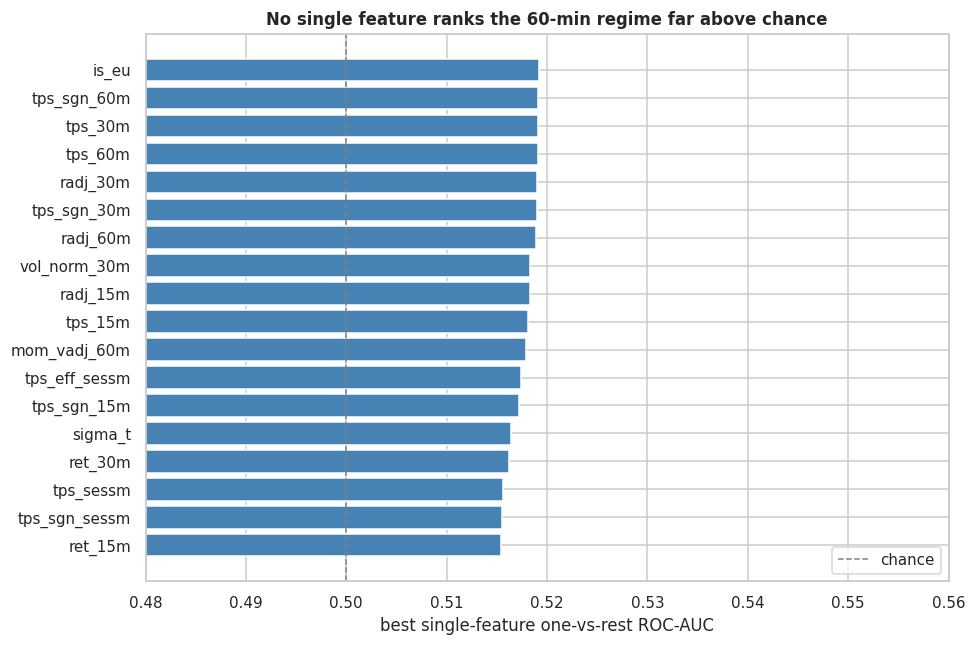

strongest single feature: is_eu at AUC 0.519
median single-feature AUC: 0.513


In [8]:
from sklearn.metrics import roc_auc_score

# Single-feature forward-regime AUC on a sample (global-quantile labels, NO_TRADE
# dropped). For each feature: max over classes of max(AUC, 1-AUC), i.e. the
# feature is allowed to point either direction.
samp = RNG.choice(len(y_all), 250_000, replace=False)
ys = y_all[samp]; keep = ys >= 0
Xs = panel[FEATURES].to_numpy()[samp][keep]
ys = ys[keep]

rows = []
for j, f in enumerate(FEATURES):
    x = Xs[:, j]
    ok = ~np.isnan(x)
    if ok.sum() < 1000:
        continue
    best = 0.5
    for c in (0, 1, 2):
        a = roc_auc_score((ys[ok] == c).astype(int), x[ok])
        best = max(best, a, 1 - a)
    rows.append((f, best))
single = pd.DataFrame(rows, columns=["feature", "best_auc"]).sort_values("best_auc", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = single.head(18)
ax.barh(top["feature"][::-1], top["best_auc"][::-1], color="steelblue")
ax.axvline(0.5, color="grey", ls="--", lw=1, label="chance")
ax.set_xlim(0.48, max(0.56, top["best_auc"].max() + 0.01))
ax.set_xlabel("best single-feature one-vs-rest ROC-AUC")
ax.set_title("No single feature ranks the 60-min regime far above chance")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print(f"strongest single feature: {single.iloc[0]['feature']} at AUC {single.iloc[0]['best_auc']:.3f}")
print(f"median single-feature AUC: {single['best_auc'].median():.3f}")

### 5.3 Does the recent path predict the next one?

The premise behind TPS is persistence: if the recent hour was a clean trend, the
next hour should be too. I test it directly, correlate backward vol-adjusted
momentum and backward TPS with the forward vol-adjusted return. Persistence
would show as a positive correlation. The numbers are essentially zero, which is
the mechanism behind the flat single-feature screen above.

In [9]:
sub = panel.sample(n=400_000, random_state=0)
fwd = sub["fwd_radj_60"].to_numpy()
checks = {
    "backward mom_vadj_60m  vs  forward r-adj": sub["mom_vadj_60m"].to_numpy(),
    "backward radj_60m      vs  forward r-adj": sub["radj_60m"].to_numpy(),
    "backward tps_60m       vs  forward r-adj": sub["tps_60m"].to_numpy(),
    "backward tps_sgn_60m   vs  forward r-adj": sub["tps_sgn_60m"].to_numpy(),
}
print("Pearson correlation (recent path vs next hour):")
for name, x in checks.items():
    ok = ~(np.isnan(x) | np.isnan(fwd))
    r = np.corrcoef(x[ok], fwd[ok])[0, 1]
    print(f"  {name}: {r:+.4f}")
print("\nA persistent market would show clearly positive numbers. These are ~0.")

Pearson correlation (recent path vs next hour):
  backward mom_vadj_60m  vs  forward r-adj: -0.0015
  backward radj_60m      vs  forward r-adj: -0.0052
  backward tps_60m       vs  forward r-adj: -0.0038
  backward tps_sgn_60m   vs  forward r-adj: -0.0045

A persistent market would show clearly positive numbers. These are ~0.


## 6. Evaluation scheme, walk-forward, with tuning held out

Market data is ordered in time, so a random train/test split would let the model
learn from the future. The honest scheme is walk-forward: train on a trailing
12-month window, test on the next month, step forward one month, repeat. Each
test month is genuinely out-of-sample, the model never saw it or anything after
it. The label thresholds are recomputed on each training window, as the spec
requires.

To tune hyperparameters without contaminating the evaluation I split the
timeline in two:

- Tuning block, the first stretch of history (through end-2012). Grid search
  with an expanding-window time-series cross-validation runs here, and only here.
- Evaluation walk-forward, every month from 2013 on. The tuned models are
  refit per fold and scored. No row from the evaluation period is ever seen
  during tuning, so no look-ahead from tuning reaches the reported metrics.

This is stricter than a single untuned baseline. It costs some folds, but the
out-of-sample claim is clean.

In [10]:
def build_folds(ts, train_m=12, test_m=1):
    start, end = ts.min().normalize(), ts.max().normalize()
    cur = (start + pd.DateOffset(months=train_m)).replace(day=1)
    rows = []
    i = 0
    while cur + pd.DateOffset(months=test_m) <= end:
        rows.append(dict(fold=i,
                         train_start=cur - pd.DateOffset(months=train_m),
                         train_end=cur, test_start=cur,
                         test_end=cur + pd.DateOffset(months=test_m)))
        cur += pd.DateOffset(months=test_m); i += 1
    return pd.DataFrame(rows)

folds = build_folds(TS)
TUNE_END = pd.Timestamp("2013-01-01", tz="UTC")
eval_folds = folds[folds["test_start"] >= TUNE_END].reset_index(drop=True)
print(f"total folds: {len(folds)}   tuning block: < {TUNE_END.date()}   "
      f"evaluation folds: {len(eval_folds)} "
      f"({eval_folds['test_start'].min().date()} -> {eval_folds['test_end'].max().date()})")

total folds: 174   tuning block: < 2013-01-01   evaluation folds: 155 (2013-01-01 -> 2025-12-01)


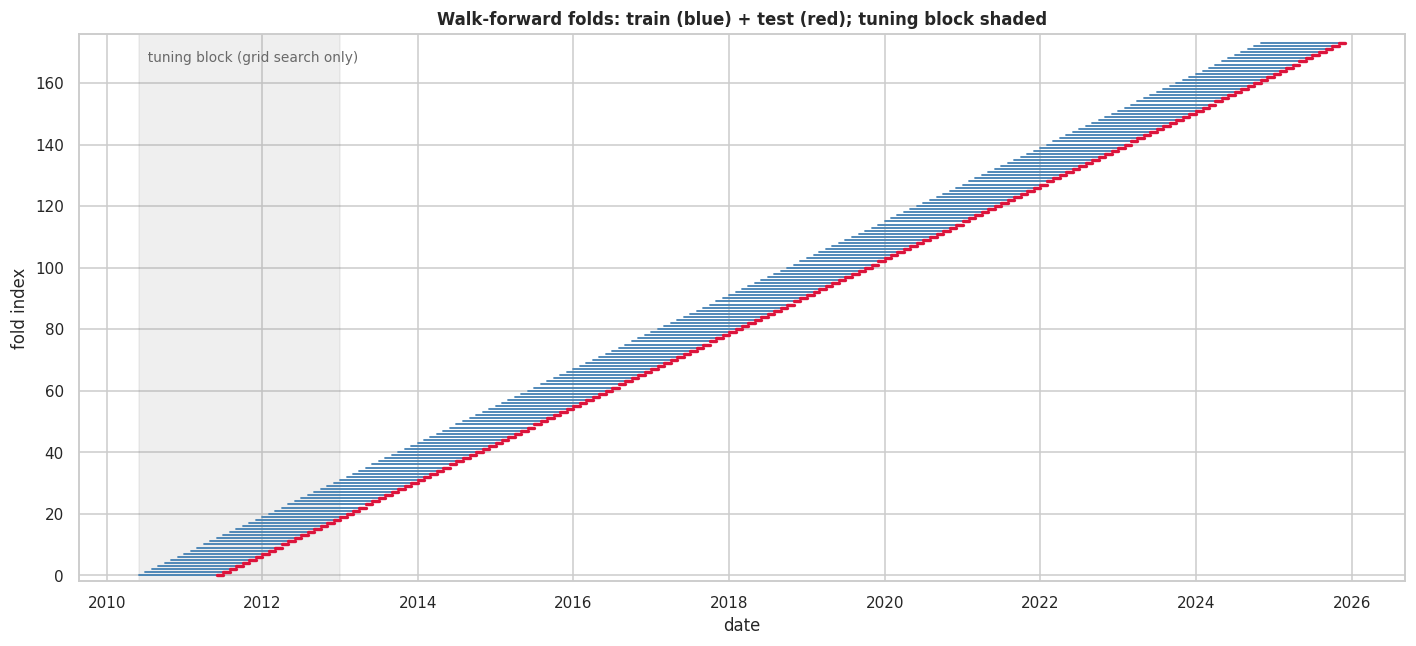

In [11]:
# Fold timeline: each fold's 12-month train (blue) and 1-month test (red),
# with the held-out tuning block shaded.
fig, ax = plt.subplots(figsize=(13, 6))
for _, r in folds.iterrows():
    ax.plot([r.train_start, r.train_end], [r.fold, r.fold], color="steelblue", lw=1.2)
    ax.plot([r.test_start, r.test_end], [r.fold, r.fold], color="crimson", lw=2.2)
ax.axvspan(folds["train_start"].min(), TUNE_END, color="grey", alpha=0.12)
ax.text(folds["train_start"].min(), len(folds) * 0.96, "  tuning block (grid search only)",
        fontsize=9, color="dimgrey")
ax.set_xlabel("date"); ax.set_ylabel("fold index")
ax.set_title("Walk-forward folds: train (blue) + test (red); tuning block shaded")
ax.set_ylim(-2, len(folds) + 2)
plt.tight_layout(); plt.show()

## 7. Models and hyperparameter search

I fit three model families, deliberately spanning the bias/variance spectrum:

- Multinomial logistic regression (L2), a linear, interpretable baseline. If the
  signal is linear, this finds it.
- Random forest, bagged decision trees. Captures non-linearity and interactions
  a linear model cannot.
- Histogram gradient boosting, boosted trees, the strongest off-the-shelf
  learner for tabular data, and fast.

Each is tuned by grid search with a 4-split expanding-window TimeSeriesSplit on
the tuning block, scored by macro-F1 (the headline metric, justified in
Section 8). Tuning on the same time-series scheme used for evaluation keeps the
protocol consistent. I keep the grids focused so the search is honest rather than
a lottery over hundreds of combinations.

In [12]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Array views for the hot paths (float32 features; forward-label ingredients;
# timestamps as datetime64 for fast fold-window masking).
XALL = panel[FEATURES].to_numpy(dtype=np.float32)
RA   = panel["fwd_radj_60"].to_numpy()
EE   = panel["fwd_E_60"].to_numpy()
SIG  = panel["sigma_t"].to_numpy()
TSV  = TS.values
# Realised forward 60-min log-return per bar, recovered from the vol-adjusted
# return: r-adj = logret / (sigma_t * sqrt(60))  ->  logret = r-adj * sigma_t * sqrt(60).
# This is the P&L the Section 10 economic test trades against.
FRET = RA * SIG * np.sqrt(60)

def q_of(idx):
    ra, e = RA[idx], EE[idx]
    return (np.quantile(ra, .70), np.quantile(ra, .30), np.quantile(e, .60),
            np.quantile(np.abs(ra), .35), np.quantile(e, .40))

def lab_of(idx, q):
    ra, e = RA[idx], EE[idx]
    y = np.full(len(idx), -1)
    y[(ra > q[0]) & (e > q[2])] = 1
    y[(ra < q[1]) & (e > q[2])] = 2
    y[(np.abs(ra) < q[3]) & (e < q[4])] = 0
    return y

# Tuning matrix: the tuning block, in chronological order, NO_TRADE dropped,
# thinned to ~180k rows preserving order so TimeSeriesSplit stays meaningful.
tune_pos = np.where((TS.values < np.datetime64(TUNE_END)))[0]
tune_pos = tune_pos[np.argsort(TS.values[tune_pos])]
ytune = lab_of(tune_pos, q_of(tune_pos))
keep = ytune >= 0
tune_pos, ytune = tune_pos[keep], ytune[keep]
if len(tune_pos) > 180_000:
    sel = np.linspace(0, len(tune_pos) - 1, 180_000).astype(int)
    tune_pos, ytune = tune_pos[sel], ytune[sel]
Xtune = XALL[tune_pos]
print(f"tuning rows: {len(ytune):,}   class counts: "
      f"{dict(zip(*np.unique([REG[v] for v in ytune], return_counts=True)))}")

tuning rows: 180,000   class counts: {np.str_('DOWN'): np.int64(48485), np.str_('MR'): np.int64(80573), np.str_('UP'): np.int64(50942)}


In [13]:
tscv = TimeSeriesSplit(n_splits=4)
t0 = time.time()

# --- Logistic regression (tuned inside a scale+impute pipeline) ---
lr_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=300, solver="lbfgs"))])
lr_grid = GridSearchCV(lr_pipe,
    {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0], "clf__class_weight": [None, "balanced"]},
    cv=tscv, scoring="f1_macro", n_jobs=-1).fit(Xtune, ytune)

# --- Random forest (native NaN; estimator single-threaded, grid parallel) ---
rf_grid = GridSearchCV(RandomForestClassifier(random_state=0, n_jobs=1),
    {"n_estimators": [200], "max_depth": [8, 12], "min_samples_leaf": [200],
     "max_features": ["sqrt", 0.3]},
    cv=tscv, scoring="f1_macro", n_jobs=-1).fit(Xtune, ytune)

# --- Histogram gradient boosting (native NaN; OpenMP internally) ---
hgb_grid = GridSearchCV(HistGradientBoostingClassifier(random_state=0),
    {"learning_rate": [0.03, 0.06, 0.1], "max_leaf_nodes": [15, 31],
     "l2_regularization": [0.0, 1.0], "max_iter": [200, 300]},
    cv=tscv, scoring="f1_macro", n_jobs=8).fit(Xtune, ytune)

TEMPLATES = {"LogReg": lr_grid.best_estimator_,
             "RandomForest": rf_grid.best_estimator_,
             "HistGB": hgb_grid.best_estimator_}
print(f"grid search done in {time.time()-t0:.0f}s\n")
for name, g in [("LogReg", lr_grid), ("RandomForest", rf_grid), ("HistGB", hgb_grid)]:
    best = {k.replace("clf__", ""): v for k, v in g.best_params_.items()}
    print(f"  {name:13s} CV macro-F1 {g.best_score_:.3f}   best: {best}")

grid search done in 733s

  LogReg        CV macro-F1 0.323   best: {'C': 0.03, 'class_weight': 'balanced'}
  RandomForest  CV macro-F1 0.257   best: {'max_depth': 12, 'max_features': 0.3, 'min_samples_leaf': 200, 'n_estimators': 200}
  HistGB        CV macro-F1 0.349   best: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_iter': 300, 'max_leaf_nodes': 15}


## 8. Out-of-sample results

Each tuned model is refit on every evaluation fold's training window and scored
on the next month. I pool the per-fold predictions and report metrics on the
whole out-of-sample stream, plus the spread across folds.

### Evaluation metric, what I report and why

- Macro-F1 is the headline. The three classes are weighted equally, so a model
  cannot win by leaning on the majority class. On an imbalanced multi-class
  target this is the metric that rewards genuinely separating all three states.
- Macro ROC-AUC sits beside it as the threshold-free ranking measure. It asks a
  cleaner question, does the model rank a true UP above a non-UP, without
  depending on where the decision cut falls. For a near-chance model this is the
  honest read.
- Accuracy is reported but is not the headline: on a 45/28/27 class split a model
  that always guesses the majority already scores ~0.45, so accuracy flatters.

Every metric is shown against three trivial baselines, always-majority,
random-in-proportion, uniform-random, so "better than chance" is a number, not
a claim.

In [14]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from joblib import Parallel, delayed

# Each fold is independent, so the loop runs folds in parallel across cores. The
# model fits inside a fold are held to one thread each (threadpool_limits), so
# the parallelism is clean: one fold per core, no oversubscription. XALL is large
# and read-only, so joblib memory-maps it to the workers rather than copying it.
def _fit_fold(tr_pos, te_pos, ytr, yte, X, templates):
    import warnings; warnings.filterwarnings("ignore")   # worker procs don't inherit the filter
    import numpy as np
    from sklearn.base import clone
    from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
    from threadpoolctl import threadpool_limits
    Xtr, Xte = X[tr_pos], X[te_pos]
    res = {}
    with threadpool_limits(1):
        for name, tmpl in templates.items():
            m = clone(tmpl).fit(Xtr, ytr)
            pr = m.predict_proba(Xte)
            yp = m.classes_[pr.argmax(1)]          # argmax column -> class label
            auc = (roc_auc_score(yte, pr, multi_class="ovr", average="macro")
                   if set(yte) == {0, 1, 2} else float("nan"))
            res[name] = (yp, pr, dict(model=name, n=int(len(yte)),
                                      accuracy=float(accuracy_score(yte, yp)),
                                      macro_f1=float(f1_score(yte, yp, average="macro")),
                                      macro_auc=float(auc)))
    return yte, res

def run_walkforward(folds_df, templates, n_jobs=32):
    # The main process builds each fold's labels (cheap); the workers fit. I also
    # keep the realised forward return per test row, aligned with the pooled
    # predictions, so Section 10 can put the signal through a cost model.
    jobs = []
    for _, r in folds_df.iterrows():
        tr = np.where((TSV >= np.datetime64(r.train_start)) & (TSV < np.datetime64(r.train_end)))[0]
        te = np.where((TSV >= np.datetime64(r.test_start)) & (TSV < np.datetime64(r.test_end)))[0]
        q = q_of(tr); ytr, yte = lab_of(tr, q), lab_of(te, q)
        ktr, kte = ytr >= 0, yte >= 0
        if ktr.sum() < 500 or kte.sum() < 50:
            continue
        tr, te, ytr, yte = tr[ktr], te[kte], ytr[ktr], yte[kte]
        if len(set(ytr)) < 3 or len(set(yte)) < 3:
            continue
        jobs.append((r.test_start, tr, te, ytr, yte))

    t0 = time.time()
    out = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(_fit_fold)(tr, te, ytr, yte, XALL, templates) for (_, tr, te, ytr, yte) in jobs)

    Y, FR, POOL, rows = [], [], {n: {"yp": [], "pr": []} for n in templates}, []
    for (ts0, _tr, te, _ytr, _yte), (yte_r, res) in zip(jobs, out):
        Y.append(yte_r); FR.append(FRET[te])
        for name, (yp, pr, mrow) in res.items():
            POOL[name]["yp"].append(yp); POOL[name]["pr"].append(pr)
            mrow = dict(mrow); mrow["test_start"] = ts0; rows.append(mrow)
    Y = np.concatenate(Y); FR = np.concatenate(FR)
    for n in templates:
        POOL[n]["yp"] = np.concatenate(POOL[n]["yp"]); POOL[n]["pr"] = np.concatenate(POOL[n]["pr"])
    print(f"walk-forward: {len(jobs)} folds, pooled {len(Y):,} rows, {time.time()-t0:.0f}s")
    return Y, POOL, pd.DataFrame(rows), FR

Y_TRUE, POOL, fold_metrics, FRET_POOL = run_walkforward(eval_folds, TEMPLATES)

# Refit each tuned model on the last evaluation fold, used by the interpretation
# pass. Three quick fits; nothing else needs the fitted objects.
_r = eval_folds.iloc[-1]
_tr = np.where((TSV >= np.datetime64(_r.train_start)) & (TSV < np.datetime64(_r.train_end)))[0]
_te = np.where((TSV >= np.datetime64(_r.test_start)) & (TSV < np.datetime64(_r.test_end)))[0]
_q = q_of(_tr); _ytr, _yte = lab_of(_tr, _q), lab_of(_te, _q)
_ktr, _kte = _ytr >= 0, _yte >= 0
LAST = {n: clone(t).fit(XALL[_tr][_ktr], _ytr[_ktr]) for n, t in TEMPLATES.items()}
LAST_TEST = (XALL[_te][_kte], _yte[_kte])
print(f"refit on last fold ({_r.test_start.date()}) for interpretation: {list(LAST)}")

walk-forward: 155 folds, pooled 2,384,716 rows, 2029s


refit on last fold (2025-11-01) for interpretation: ['LogReg', 'RandomForest', 'HistGB']


In [15]:
# Pooled out-of-sample metrics per model, plus the three trivial baselines.
def pooled_metrics(y, yp, pr):
    return dict(accuracy=accuracy_score(y, yp),
                macro_f1=f1_score(y, yp, average="macro"),
                macro_auc=roc_auc_score(y, pr, multi_class="ovr", average="macro"))

cls, cnt = np.unique(Y_TRUE, return_counts=True)
freq = cnt / cnt.sum()
maj  = np.full(len(Y_TRUE), cls[freq.argmax()])
prop = RNG.choice(cls, size=len(Y_TRUE), p=freq)
unif = RNG.choice(cls, size=len(Y_TRUE))

summary = []
for name in TEMPLATES:
    m = pooled_metrics(Y_TRUE, POOL[name]["yp"], POOL[name]["pr"])
    summary.append((name, m["accuracy"], m["macro_f1"], m["macro_auc"]))
summary += [
    ("majority-class",  accuracy_score(Y_TRUE, maj),  f1_score(Y_TRUE, maj,  average="macro"), 0.500),
    ("random-in-prop.", accuracy_score(Y_TRUE, prop), f1_score(Y_TRUE, prop, average="macro"), 0.500),
    ("uniform-random",  accuracy_score(Y_TRUE, unif), f1_score(Y_TRUE, unif, average="macro"), 0.500),
]
summary = pd.DataFrame(summary, columns=["model", "accuracy", "macro_f1", "macro_auc"])
BEST = summary.iloc[:3].sort_values("macro_auc", ascending=False)["model"].iloc[0]
print(f"majority-class share (accuracy floor): {freq.max():.3f}")
print(f"best model by macro-AUC: {BEST}\n")
summary.round(3)

majority-class share (accuracy floor): 0.445
best model by macro-AUC: RandomForest



,model,accuracy,macro_f1,macro_auc
0,LogReg,0.362,0.357,0.534
1,RandomForest,0.436,0.281,0.535
2,HistGB,0.389,0.354,0.530
3,majority-class,0.445,0.205,0.500
4,random-in-prop.,0.352,0.333,0.500
5,uniform-random,0.333,0.328,0.500


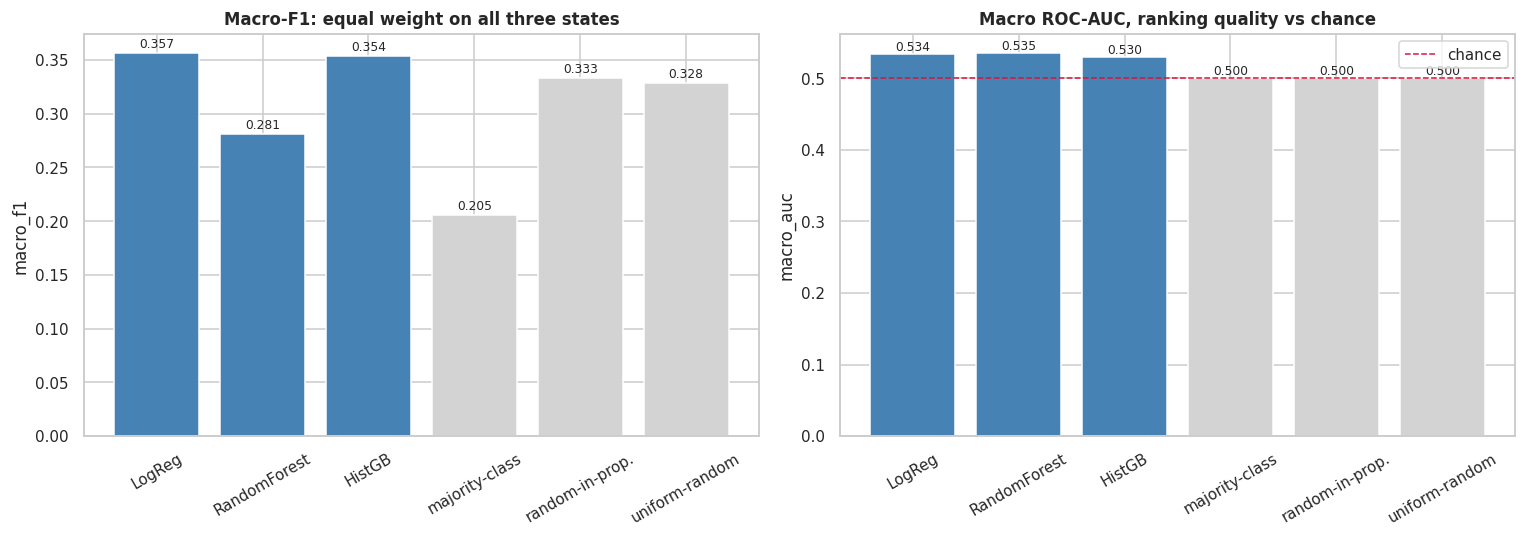

In [16]:
# Model vs baselines, the two headline metrics side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = summary["model"].tolist()
pal = ["steelblue"] * 3 + ["lightgrey"] * 3
for ax, col, title, ref, refname in [
        (axes[0], "macro_f1",  "Macro-F1: equal weight on all three states", None, None),
        (axes[1], "macro_auc", "Macro ROC-AUC, ranking quality vs chance", 0.5, "chance")]:
    ax.bar(order, summary[col], color=pal)
    ax.set_title(title); ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=30)
    if ref is not None:
        ax.axhline(ref, color="crimson", ls="--", lw=1, label=refname); ax.legend()
    for i, v in enumerate(summary[col]):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

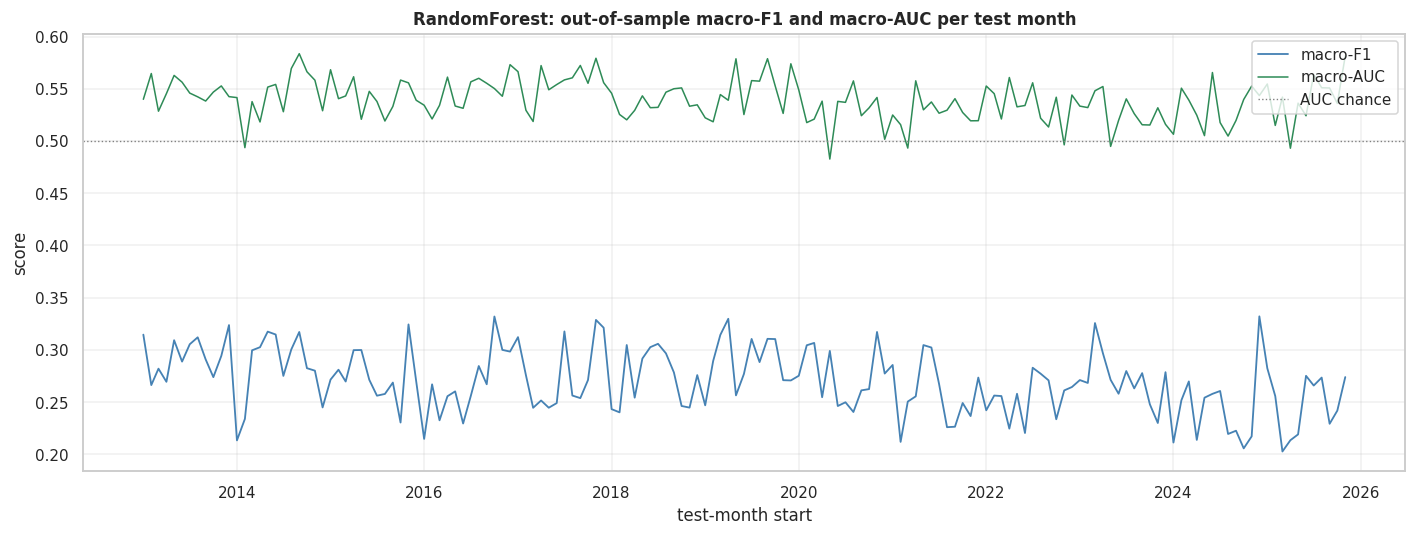

      macro_f1  macro_auc  accuracy
mean     0.270      0.539     0.436
std      0.031      0.020     0.027


In [17]:
# Per-fold stability of the best model, is the near-chance behaviour persistent?
fm = fold_metrics[fold_metrics["model"] == BEST]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fm["test_start"], fm["macro_f1"],  color="steelblue", lw=1.2, label="macro-F1")
ax.plot(fm["test_start"], fm["macro_auc"], color="seagreen", lw=1.0, label="macro-AUC")
ax.axhline(0.5, color="grey", ls=":", lw=0.9, label="AUC chance")
ax.set_title(f"{BEST}: out-of-sample macro-F1 and macro-AUC per test month")
ax.set_xlabel("test-month start"); ax.set_ylabel("score")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(fm[["macro_f1", "macro_auc", "accuracy"]].agg(["mean", "std"]).round(3))

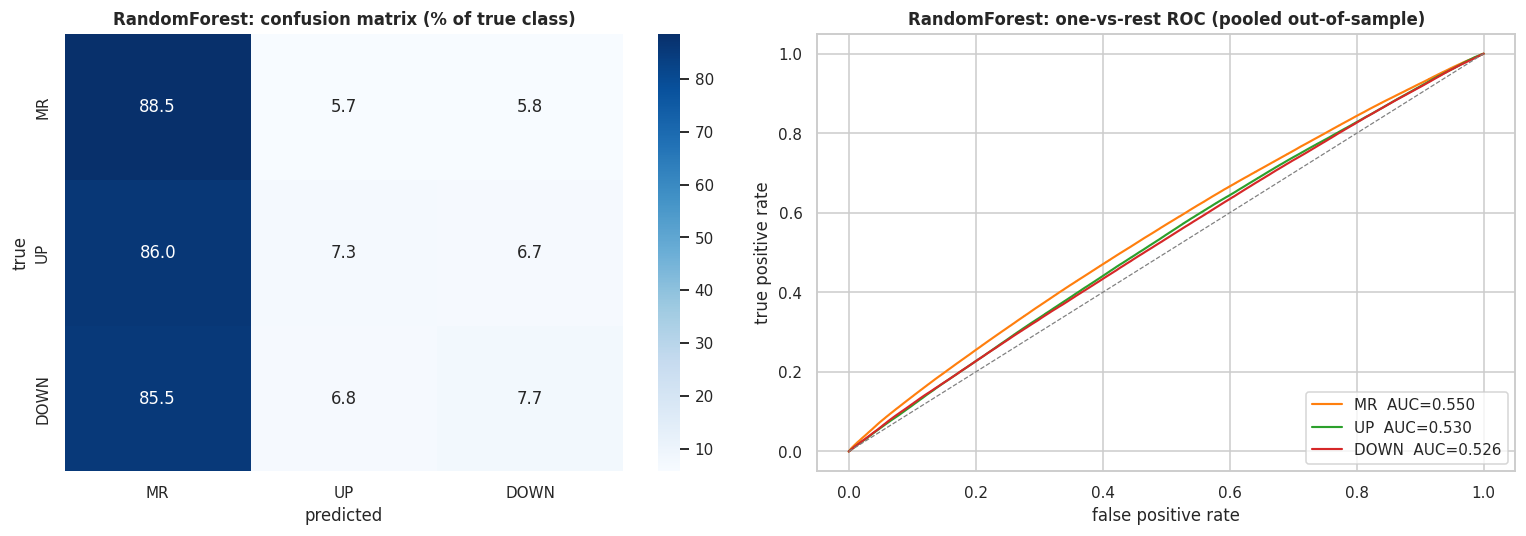

In [18]:
# Pooled confusion matrix + per-class ROC for the best model.
from sklearn.metrics import confusion_matrix, roc_curve, auc
names3 = [REG[i] for i in (0, 1, 2)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(Y_TRUE, POOL[BEST]["yp"], labels=[0, 1, 2])
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=names3, yticklabels=names3, ax=axes[0])
axes[0].set_title(f"{BEST}: confusion matrix (% of true class)")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")

pr = POOL[BEST]["pr"]
for k, color in zip((0, 1, 2), ["tab:orange", "tab:green", "tab:red"]):
    fpr, tpr, _ = roc_curve((Y_TRUE == k).astype(int), pr[:, list(LAST[BEST].classes_).index(k)])
    axes[1].plot(fpr, tpr, lw=1.4, color=color, label=f"{REG[k]}  AUC={auc(fpr, tpr):.3f}")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=0.8)
axes[1].set_title(f"{BEST}: one-vs-rest ROC (pooled out-of-sample)")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

### Reading the results

All three models sit on top of each other, a few points off the floor. Macro
ROC-AUC is about 0.53, a small but consistent step above chance. Accuracy is at
or below the majority-class share: the random forest leans on the majority class
to hold accuracy at the cost of macro-F1, while the linear model and gradient
boosting spread their guesses across the classes and give up top-1 in exchange.
The macro-F1 sits around the proportional-guess baseline.

The confusion matrix shows the mechanism: predictions smear across the diagonal
more than they concentrate on it, and the ROC curves bow only slightly off the
diagonal. A linear model and two non-linear ensembles agreeing this closely is
the tell: the ceiling sits in the data, not in the estimator. Two questions
follow. Is that 0.53 real or is it noise (Section 9)? And if it is real, does it
survive the cost of trading it (Section 10)? The interpretation pass in Section 11
then asks where, if anywhere, the faint edge lives inside the models.

## 9. Is the result distinguishable from chance?

A macro-AUC near 0.53 is a few points above chance. Is that small gap real
signal, or sampling noise? That needs a confidence statement, not an eyeball. I
test the best model's macro ROC-AUC three ways:

1. Across-fold t-test. Treat each fold's macro-AUC as one observation and test
   the mean against 0.50 (one-sample t-test), with a 95% confidence interval.
2. Bootstrap on the pooled stream. Resample the out-of-sample rows with
   replacement and recompute AUC to get a non-parametric 95% interval.
3. Label permutation. Shuffle the labels many times and recompute AUC to build
   the null distribution, then locate the observed value in it.

A note on what "significant" means here. With millions of rows even a 0.02 edge
can be statistically distinguishable from 0.50. Statistical significance and
economic significance are two different questions: an edge can be real and
detectable, and still disappear the moment you pay to trade it. This section
settles the first (is it real?); Section 10 settles the second (does it pay?).

In [19]:
from scipy import stats

fm_best = fold_metrics[fold_metrics["model"] == BEST]["macro_auc"].dropna().to_numpy()
m, sd, nF = fm_best.mean(), fm_best.std(ddof=1), len(fm_best)
ci = stats.t.interval(0.95, nF - 1, loc=m, scale=sd / np.sqrt(nF))
t_stat, p_t = stats.ttest_1samp(fm_best, 0.5)
print(f"[1] Across {nF} folds: mean macro-AUC {m:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"    t-test vs 0.50:  t={t_stat:.2f}  p={p_t:.2e}   effect size = {m-0.5:+.4f} AUC")

# [2] bootstrap pooled AUC (subsample for speed; robust at 200k x 200 resamples)
ss = RNG.choice(len(Y_TRUE), 200_000, replace=False)
y_ss, pr_ss = Y_TRUE[ss], POOL[BEST]["pr"][ss]
boot = []
for _ in range(200):
    b = RNG.integers(0, len(y_ss), len(y_ss))
    if set(y_ss[b]) == {0, 1, 2}:
        boot.append(roc_auc_score(y_ss[b], pr_ss[b], multi_class="ovr", average="macro"))
boot = np.array(boot)
print(f"[2] Bootstrap pooled macro-AUC: {boot.mean():.4f}  "
      f"95% CI [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

# [3] label-permutation null
perm = np.array([roc_auc_score(RNG.permutation(y_ss), pr_ss, multi_class="ovr", average="macro")
                 for _ in range(200)])
obs = roc_auc_score(y_ss, pr_ss, multi_class="ovr", average="macro")
print(f"[3] Permutation null AUC: {perm.mean():.4f} +/- {perm.std():.4f}   "
      f"observed {obs:.4f}   p={(perm >= obs).mean():.3f}")

# McNemar-style check vs always-majority on the pooled stream
mc = np.full(len(Y_TRUE), cls[freq.argmax()])
mod_ok = POOL[BEST]["yp"] == Y_TRUE; maj_ok = mc == Y_TRUE
b = int((mod_ok & ~maj_ok).sum()); c = int((~mod_ok & maj_ok).sum())
chi2 = (abs(b - c) - 1) ** 2 / (b + c); p_mc = stats.chi2.sf(chi2, 1)
print(f"\nvs always-majority: model wins {b:,} rows, loses {c:,}  "
      f"(McNemar chi2={chi2:.0f}, p={p_mc:.1e}) -> model does not beat the majority guess")

[1] Across 155 folds: mean macro-AUC 0.5393  95% CI [0.5362, 0.5425]
    t-test vs 0.50:  t=24.79  p=1.23e-55   effect size = +0.0393 AUC


[2] Bootstrap pooled macro-AUC: 0.5355  95% CI [0.5332, 0.5374]


[3] Permutation null AUC: 0.5000 +/- 0.0010   observed 0.5355   p=0.000

vs always-majority: model wins 99,152 rows, loses 121,786  (McNemar chi2=2319, p=0.0e+00) -> model does not beat the majority guess


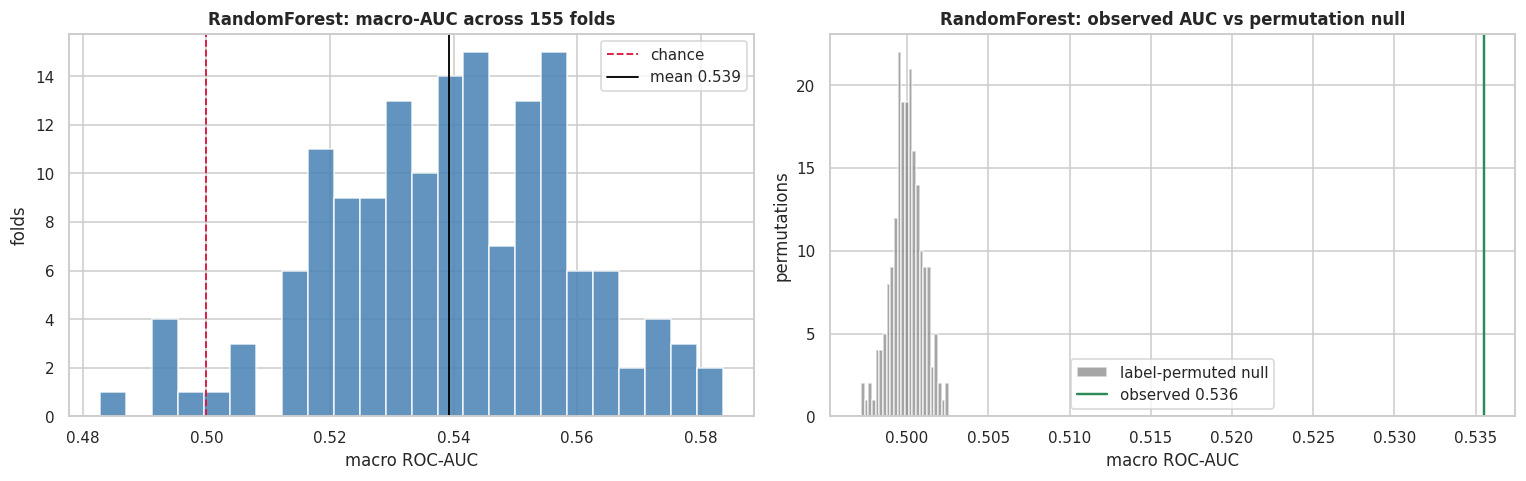

In [20]:
# Visualise the null: per-fold AUC spread, and the permutation distribution.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(fm_best, bins=24, color="steelblue", alpha=0.85)
axes[0].axvline(0.5, color="crimson", ls="--", lw=1.2, label="chance")
axes[0].axvline(m, color="black", lw=1.2, label=f"mean {m:.3f}")
axes[0].set_title(f"{BEST}: macro-AUC across {nF} folds")
axes[0].set_xlabel("macro ROC-AUC"); axes[0].set_ylabel("folds"); axes[0].legend()

axes[1].hist(perm, bins=24, color="grey", alpha=0.7, label="label-permuted null")
axes[1].axvline(obs, color="seagreen", lw=1.6, label=f"observed {obs:.3f}")
axes[1].set_title(f"{BEST}: observed AUC vs permutation null")
axes[1].set_xlabel("macro ROC-AUC"); axes[1].set_ylabel("permutations"); axes[1].legend()
plt.tight_layout(); plt.show()

## 10. Does the edge survive costs?

Section 9 says the 0.53 is real. The next question is the one that matters to a
desk: is it worth trading. I turn the best model's calls into a plain long/short
book (long when it says UP, short when it says DOWN, flat on MR) and measure the
realised forward return per decision, in basis points, before and after a
transaction cost. Then a cumulative P&L on non-overlapping one-hour holds. Costs
are the whole story here: CL front month is a one-tick market, so a round trip
across the spread plus fees lands around 2 to 3 bps.

In [21]:
# Predictions -> long/short book. FRET_POOL is the realised forward 60-min
# log-return, aligned row-for-row with the pooled predictions (Section 8).
yp  = POOL[BEST]["yp"]
pos = np.where(yp == 1, 1.0, np.where(yp == 2, -1.0, 0.0))   # +1 UP, -1 DOWN, 0 MR
traded = pos != 0
gross  = pos * FRET_POOL
g_bps  = gross[traded].mean() * 1e4                          # gross edge per trade, bps
hit    = (np.sign(gross[traded]) > 0).mean()                 # directional hit-rate

print(f"decisions: {len(pos):,}   traded UP/DOWN: {traded.sum():,} ({traded.mean():.0%})")
print(f"gross edge per trade: {g_bps:+.2f} bps     directional hit-rate: {hit:.3f}\n")
print("realised forward return, conditional on the call:")
for c, name in [(1, "UP"), (2, "DOWN"), (0, "MR")]:
    msk = yp == c
    print(f"  E[fwd ret | {name:4s}] = {FRET_POOL[msk].mean()*1e4:+.2f} bps   (n={int(msk.sum()):,})")
print("\nnet edge per trade, after a round-trip transaction cost:")
for rt in [1.0, 1.5, 2.0, 3.0]:
    net = g_bps - rt
    print(f"  round-trip {rt:>3.1f} bps  ->  net {net:+.2f} bps  ({'positive' if net > 0 else 'negative'})")

decisions: 2,384,716   traded UP/DOWN: 310,199 (13%)
gross edge per trade: +0.92 bps     directional hit-rate: 0.499

realised forward return, conditional on the call:
  E[fwd ret | UP  ] = +0.32 bps   (n=153,525)
  E[fwd ret | DOWN] = -1.51 bps   (n=156,674)
  E[fwd ret | MR  ] = -0.30 bps   (n=2,074,517)

net edge per trade, after a round-trip transaction cost:
  round-trip 1.0 bps  ->  net -0.08 bps  (negative)
  round-trip 1.5 bps  ->  net -0.58 bps  (negative)
  round-trip 2.0 bps  ->  net -1.08 bps  (negative)
  round-trip 3.0 bps  ->  net -2.08 bps  (negative)


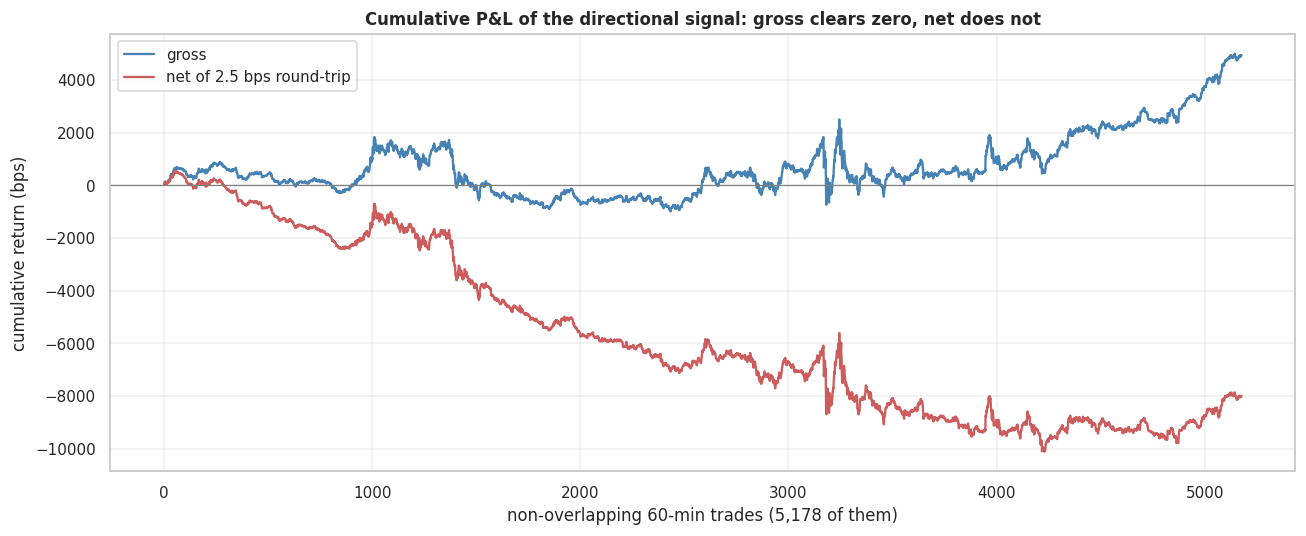

non-overlapping trades: 5,178   gross total +4944 bps   net total -8001 bps


In [22]:
# Cumulative P&L on non-overlapping 60-min holds (every 60th pooled decision, so
# positions do not overlap), gross vs net of a 2.5 bps round-trip, mid of the CL
# front-month range. Equal size, no compounding: a first-order look, not a
# production backtest.
step, rt = 60, 2.5e-4
p, f = pos[::step], FRET_POOL[::step]
tr = p != 0                                   # keep only the bars we actually trade
p, f = p[tr], f[tr]
gross_curve = np.cumsum(p * f) * 1e4
net_curve   = np.cumsum(p * f - rt) * 1e4     # one round-trip cost per trade
n_tr = len(p)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gross_curve, color="steelblue", lw=1.5, label="gross")
ax.plot(net_curve,   color="indianred", lw=1.5, label="net of 2.5 bps round-trip")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Cumulative P&L of the directional signal: gross clears zero, net does not")
ax.set_xlabel(f"non-overlapping 60-min trades ({n_tr:,} of them)")
ax.set_ylabel("cumulative return (bps)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"non-overlapping trades: {n_tr:,}   "
      f"gross total {gross_curve[-1]:+.0f} bps   net total {net_curve[-1]:+.0f} bps")

The signal earns a faint positive edge gross, under a basis point per trade,
leaning on the short side: the model's DOWN calls sit in front of the larger moves.
Gross, the equity curve climbs. But the edge is smaller than the spread you pay to capture
it: net of even a one-tick round trip it is negative, and at the 2 to 3 bps it
actually costs to cross in CL front month the curve rolls over hard. The hit-rate at
50% says the same from another angle, this is not a clean directional call, it is a
faint magnitude tilt on the short side, smaller than the cost of harvesting it.

This is what an efficient market looks like from the inside. The information is not
quite zero, but it is already priced to within the bid-ask. A model that ignores
costs would book the gross line and call it alpha. The net line is the honest one.

## 11. Looking inside the models

The edge is real but tiny, so the question here is not which feature matters most.
It is whether the edge is concentrated in a few features or smeared thin across
many. I open the models three ways: permutation importance (model-agnostic), the
linear model's coefficients, and partial dependence for the features the best
model leans on hardest.

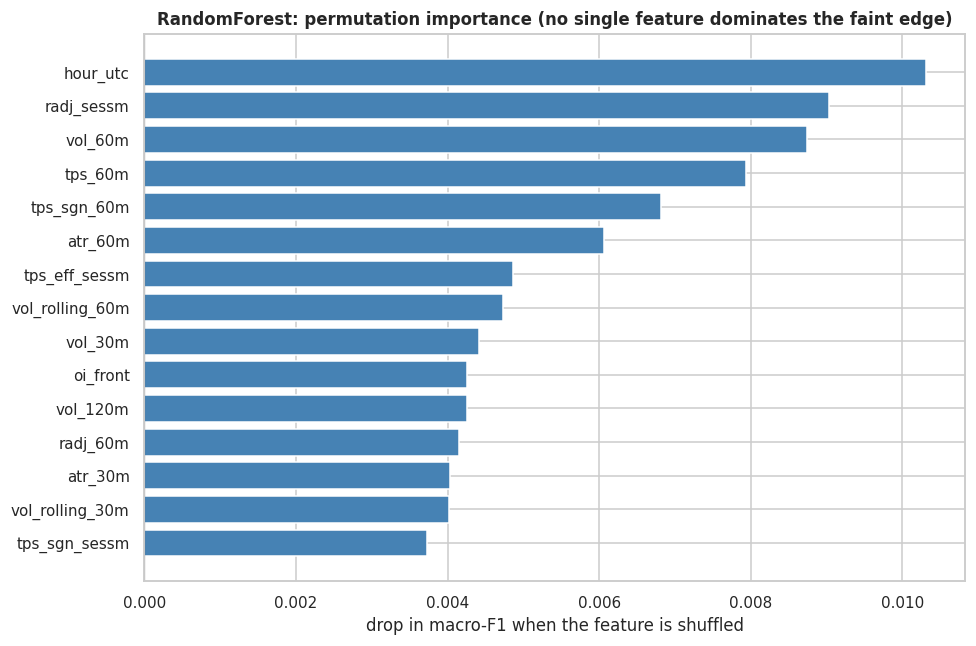

largest single-feature F1 drop: 0.0103  (a dominant driver would cost several points; here the edge is spread thin)


In [23]:
from sklearn.inspection import permutation_importance

# Permutation importance for the best model, on a sample of its last-fold test set.
Xpi, ypi = LAST_TEST
s = RNG.choice(len(ypi), min(8000, len(ypi)), replace=False)
pi = permutation_importance(LAST[BEST], Xpi[s], ypi[s], scoring="f1_macro",
                            n_repeats=5, random_state=0, n_jobs=-1)
imp = pd.DataFrame({"feature": FEATURES, "drop": pi.importances_mean}).sort_values("drop", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15)
ax.barh(top["feature"][::-1], top["drop"][::-1], color="steelblue")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("drop in macro-F1 when the feature is shuffled")
ax.set_title(f"{BEST}: permutation importance (no single feature dominates the faint edge)")
plt.tight_layout(); plt.show()
print(f"largest single-feature F1 drop: {imp['drop'].max():.4f}  "
      f"(a dominant driver would cost several points; here the edge is spread thin)")

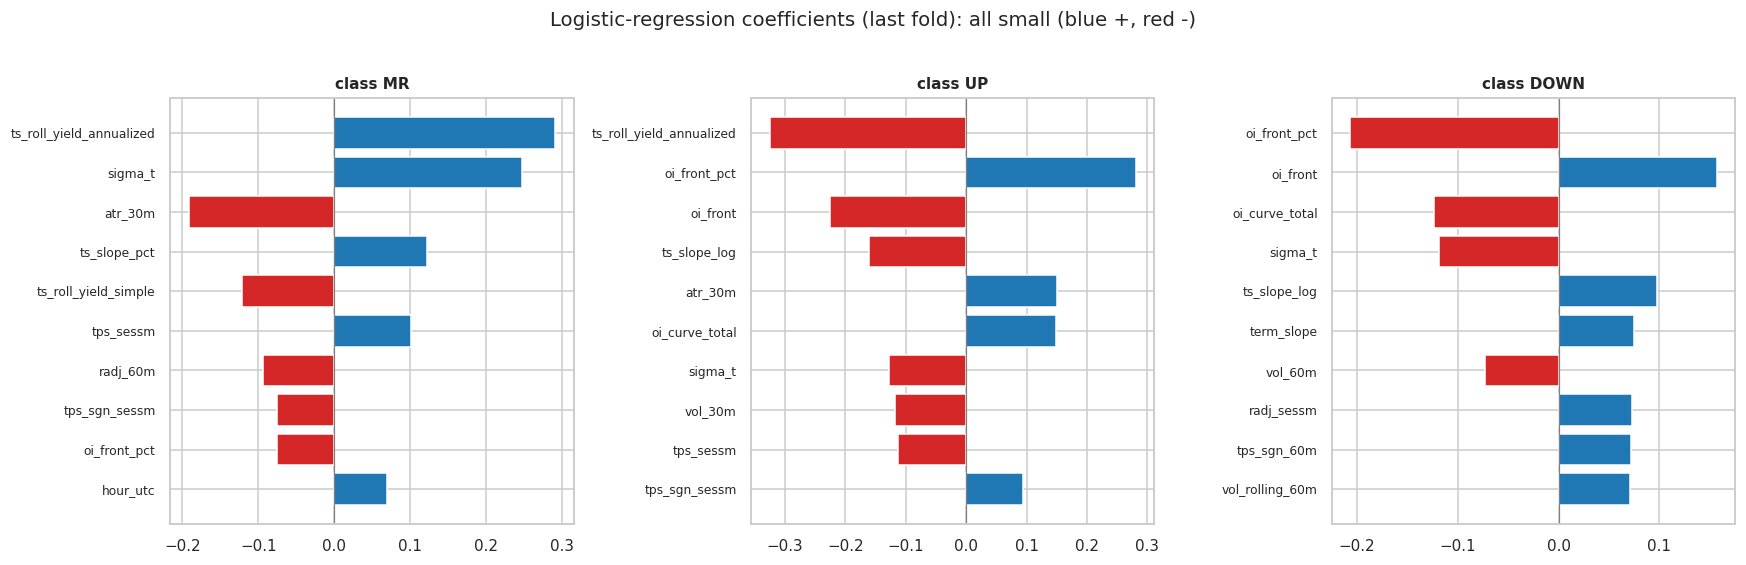

In [24]:
# Logistic-regression coefficients per class (last fold), sign and magnitude.
lr = LAST["LogReg"].named_steps["clf"]
coef = pd.DataFrame(lr.coef_, columns=FEATURES, index=[REG[c] for c in lr.classes_])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (clsname, row) in zip(axes, coef.iterrows()):
    top = row.abs().sort_values(ascending=False).head(10)
    vals = row.reindex(top.index)
    ax.barh(top.index[::-1], vals.values[::-1],
            color=["tab:blue" if v > 0 else "tab:red" for v in vals.values[::-1]])
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(f"class {clsname}", fontsize=10); ax.tick_params(axis="y", labelsize=8)
plt.suptitle("Logistic-regression coefficients (last fold): all small (blue +, red -)", y=1.02)
plt.tight_layout(); plt.show()

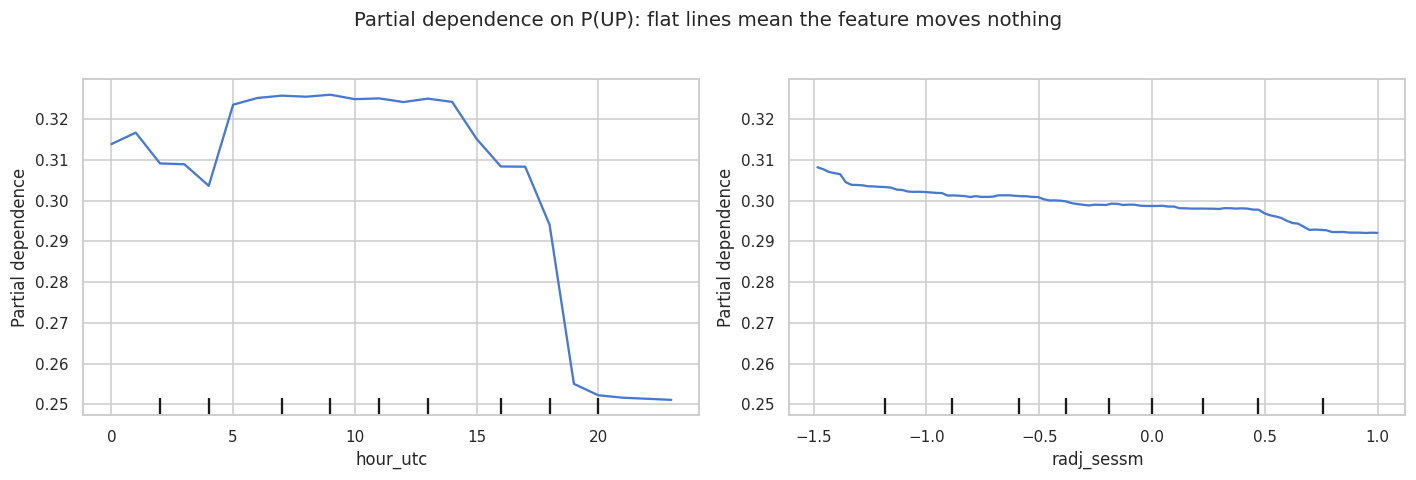

In [25]:
# Partial dependence for the two features the best model ranked highest.
from sklearn.inspection import PartialDependenceDisplay
top2 = [FEATURES.index(f) for f in imp.head(2)["feature"]]
Xpd = Xpi[RNG.choice(len(ypi), min(5000, len(ypi)), replace=False)]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
PartialDependenceDisplay.from_estimator(LAST[BEST], Xpd, top2, feature_names=FEATURES,
                                        target=1, ax=ax)  # target=UP
fig.suptitle("Partial dependence on P(UP): flat lines mean the feature moves nothing", y=1.03)
plt.tight_layout(); plt.show()

The three views agree. Permutation importance is near zero for every feature:
shuffling any one of them barely moves macro-F1, so no single feature carries the
edge; it is spread thin across many. The logistic coefficients are all small, with
no class leaning on a clear handful of features. The partial-dependence curves are
close to flat. Nothing here contradicts Section 10: the edge is faint, distributed
and, once costs are paid, not worth harvesting.

## 12. Findings

### What I asked

Can the next hour of WTI crude direction, up, down or sideways, be predicted from
price, volatility, term-structure, open-interest and options signals, out of sample
and without look-ahead.

### What I found

There is a signal, but it is smaller than the spread. Three model families, each
tuned by grid search and tested across about 155 months of walk-forward, all land
at macro-AUC about 0.53, a few points above chance, and a hypothesis test confirms
the gap is real, not sampling noise. Turned into a long/short book the signal makes
under a basis point per trade gross (about +0.9 bps), leaning on the short side.
That does not clear the cost of trading it: net of even a one-tick round trip it is
negative, and at the 2 to 3 bps you pay to cross in CL front month it is a clear
loss. A linear model and two non-linear ensembles agree to the decimal, so the
ceiling is in the data and not in the estimator; and no single feature carries the
edge: the models reach 0.53 only by stacking many faint ones together.

### What it means for a non-technical reader

- WTI front month is among the most efficient and most liquid markets in the world.
  On a one-hour view it does not give its next move away for free.
- There is a faint directional signal and it is genuine. But it is so small that the
  cost of trading it, the bid-ask spread plus fees, eats it whole. Gross it looks
  like a thin profit; net of costs it is a loss.
- So the practical answer is the same as a flat no: do not run a 60-minute
  directional model on this data and expect to make money after costs. The
  interesting part is the why: not because the market is random, but because it is
  efficient to within the cost of trading.

### Actionable items

- Do not deploy a 60-minute directional model on this feature set. The gross edge
  does not clear realistic transaction costs.
- Judge any future signal net of costs from the first day, never gross. A gross
  equity curve that climbs is not the same thing as money.
- To beat an efficient market on a one-hour horizon, the edge has to come from
  information this matrix does not hold (see below), not from a better estimator on
  the same features.

### Recommendations and next steps

These are hypotheses, not results. This dataset cannot test them, which is exactly
the point of listing them.

- Order book / L2 microstructure. On a 60-minute horizon the signal, if it is there
  at all, lives in the book: depth, queue imbalance, trade flow, the shape of the
  resting orders. A bar-level matrix throws all of that away. Rebuilding the features
  from L2 data is the first thing I would try.
- The macro context. WTI is not traded in isolation. It moves with equity vol (VIX),
  with refining margins (the crack spreads, RBOB and heating oil), with its own
  curve and grade basis (Brent-WTI), and with the dollar and rates. Adding these
  cross-asset features is the obvious second extension.
- Longer horizons. The slow features here (term structure, open interest, the vol
  surface) move day to day, not minute to minute. They may carry more at a one-day
  or one-week horizon than at sixty minutes.
- Costs in the loop. Whatever the target, score it net of a realistic spread and
  slippage from day one, so a thin gross edge is never mistaken for a tradeable one.

## 13. Conclusion and limitations

### Conclusion

I set out to predict the 60-minute-forward regime of WTI crude, and to test it the
way a desk would: time-series cross-validation, three tuned model families, out of
sample across a long walk-forward, and then a P&L net of costs. The result is a
narrow and honest one. A real directional signal exists (about 0.53 macro-AUC,
under a basis point per trade gross), but it is smaller than the bid-ask, so net of
a realistic transaction cost it does not survive. WTI front month is among the most
efficient markets in the world, and on a one-hour horizon that is exactly what the
data says: the little information there is, is already in the price.

I take that as a result, not a failure. It shows with numbers where not to spend
research budget (a tuned directional model on bar-level WTI features), and it
points the next effort at the two places an edge could still sit: the order book,
and the macro context around the contract.

### Limitations

- One instrument, one horizon. WTI crude, 60-minute forward. The conclusion does
  not automatically carry over to other markets or other horizons.
- Feature scope. Bar-level features only: no order-book / L2 microstructure, and no
  cross-asset or macro data beyond the contract's own curve and open interest. This
  is the main limitation, and the main next step.
- Cost model. The economic test uses a flat per-trade round-trip cost and equal
  sizing on non-overlapping holds. It is a first-order check, not a full execution
  model: no queue position, no market impact, no slippage tail. A more careful model
  would only push the net line further down, not up.
- Label sensitivity. The result is specific to the spec label and its quantile
  cut-offs. They are principled, but a choice; a different label is a different
  question.
- Tuning approximation. Hyperparameters were tuned once on an early block and held
  fixed rather than re-tuned every fold. Per-fold tuning is more faithful but far
  heavier, and given how flat the surface is it would not move the conclusion.